# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Heart Failure Prediction** yang bersumber dari Kaggle.

- **Sumber**: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
- **Jumlah Baris**: 918
- **Jumlah Fitur**: 12 (11 fitur + 1 target)
- **Target**: `HeartDisease` — binary classification (0 = tidak ada penyakit jantung, 1 = ada penyakit jantung)
- **Fitur Numerikal**: Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak
- **Fitur Kategorikal**: Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope

Tujuan: Membangun model klasifikasi untuk memprediksi risiko penyakit jantung berdasarkan fitur-fitur klinis pasien.

# **2. Import Library**

Import library Python yang dibutuhkan untuk analisis data dan pembangunan model.

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


# **3. Memuat Dataset**

Memuat dataset Heart Failure Prediction dari file CSV ke dalam pandas DataFrame. Dilakukan pengecekan awal untuk memahami struktur data dan memastikan data telah dimuat dengan benar.

In [5]:
df = pd.read_csv('../heart_failure_raw/heart.csv')

print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}\n')

print('5 Baris pertama:')
display(df.head())

print('\n5 Baris terakhir:')
display(df.tail())

Shape dataset: (918, 12)
Jumlah baris: 918
Jumlah kolom: 12

5 Baris pertama:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



5 Baris terakhir:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [6]:
# Informasi tipe data dan missing value
print('Info dataset:')
df.info()

print('\nJumlah missing value per kolom:')
print(df.isnull().sum())

print('\nJumlah duplikasi:')
print(f'Total baris duplikat: {df.duplicated().sum()}')

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Jumlah missing value per kolom:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR          

# **4. Exploratory Data Analysis (EDA)**

Melakukan eksplorasi untuk memahami karakteristik dataset:
- Statistik deskriptif
- Distribusi fitur numerikal
- Distribusi fitur kategorikal
- Korelasi antar fitur
- Analisis target imbalance

In [7]:
# Statistik deskriptif
print('Statistik Deskriptif - Fitur Numerikal:')
display(df.describe())

print('\nStatistik Deskriptif - Fitur Kategorikal:')
display(df.describe(include='object'))

Statistik Deskriptif - Fitur Numerikal:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000



Statistik Deskriptif - Fitur Kategorikal:


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


In [8]:
# Cek nilai unik pada fitur kategorikal
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


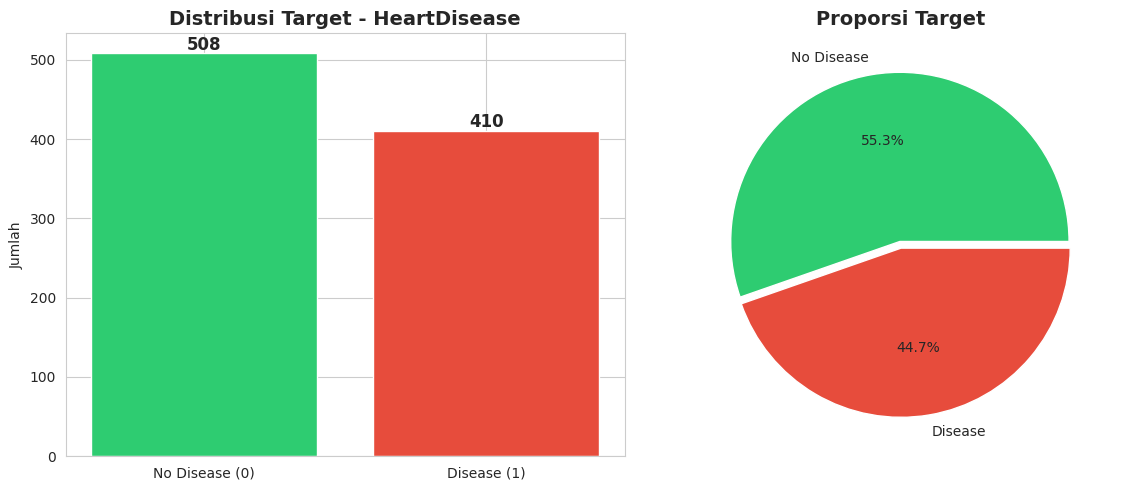

Target distribution:
  No Disease (0): 410 (44.7%)
  Disease (1):    508 (55.3%)


In [9]:
# Distribusi target
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['HeartDisease'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax[0].bar(['No Disease (0)', 'Disease (1)'], target_counts.values, color=colors)
ax[0].set_title('Distribusi Target - HeartDisease', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')

ax[1].pie(target_counts.values, labels=['No Disease', 'Disease'],
          autopct='%1.1f%%', colors=colors, explode=(0.02, 0.02))
ax[1].set_title('Proporsi Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Target distribution:')
print(f'  No Disease (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)')
print(f'  Disease (1):    {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)')

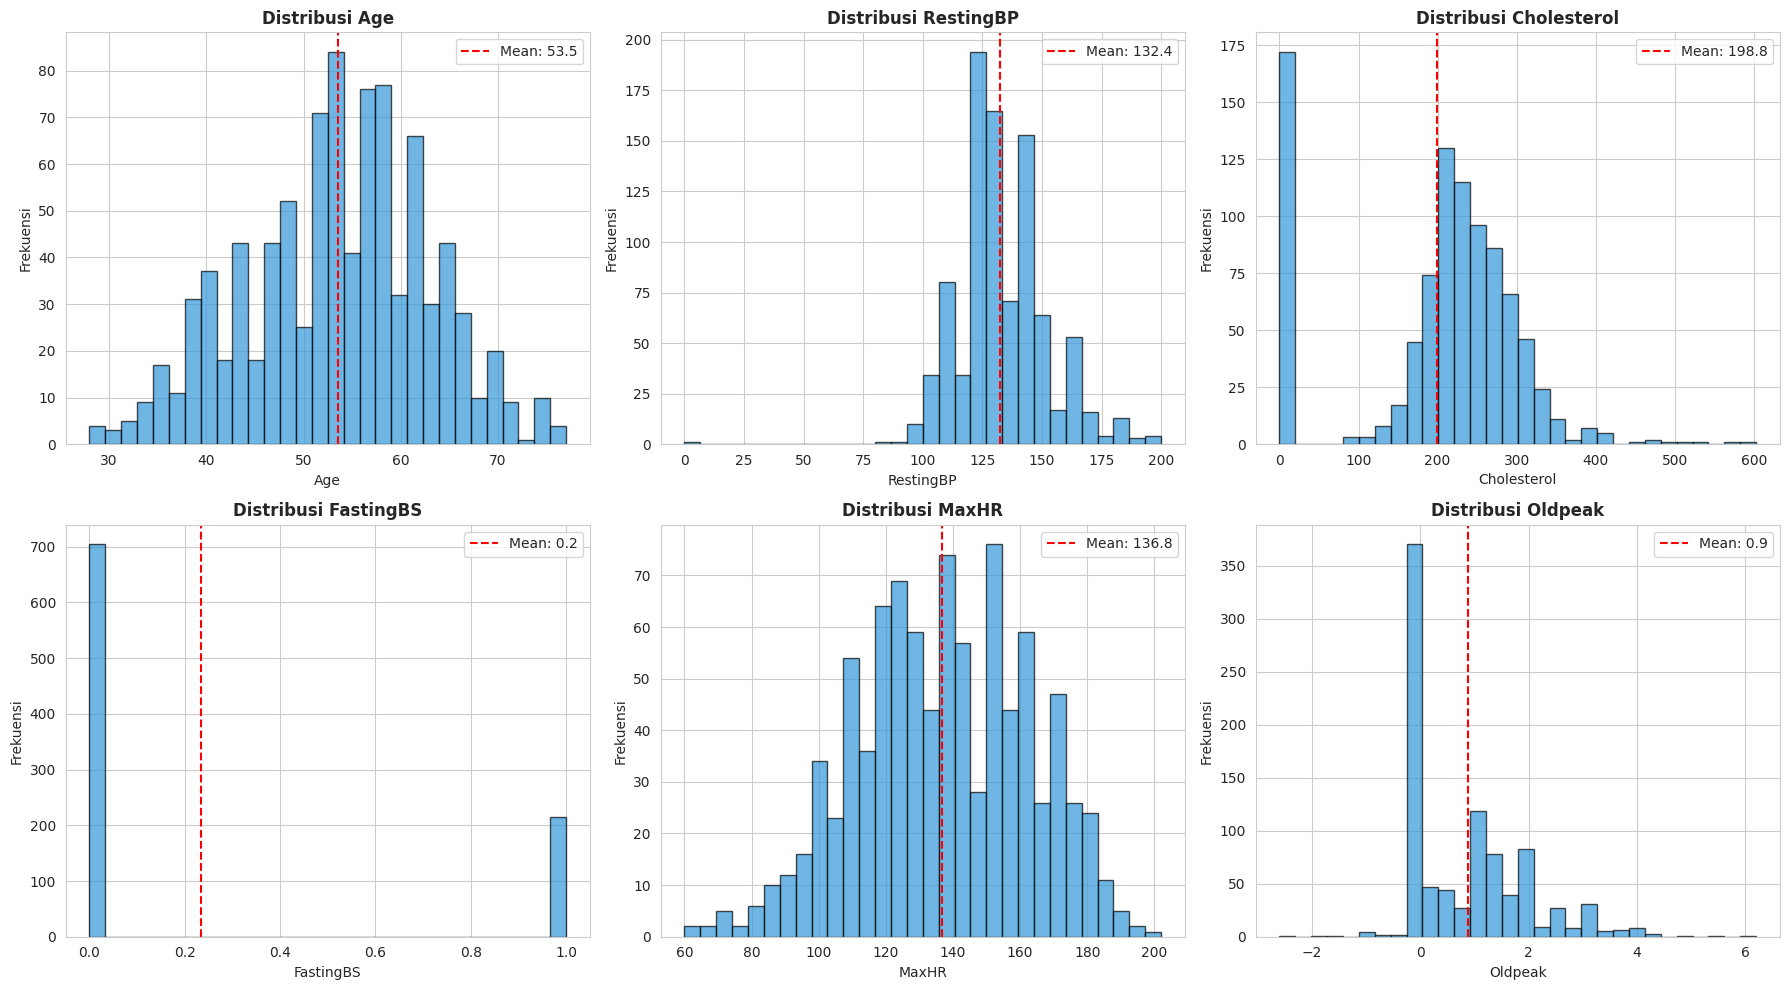

In [10]:
# Distribusi fitur numerikal
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

    # Tambahkan garis mean
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

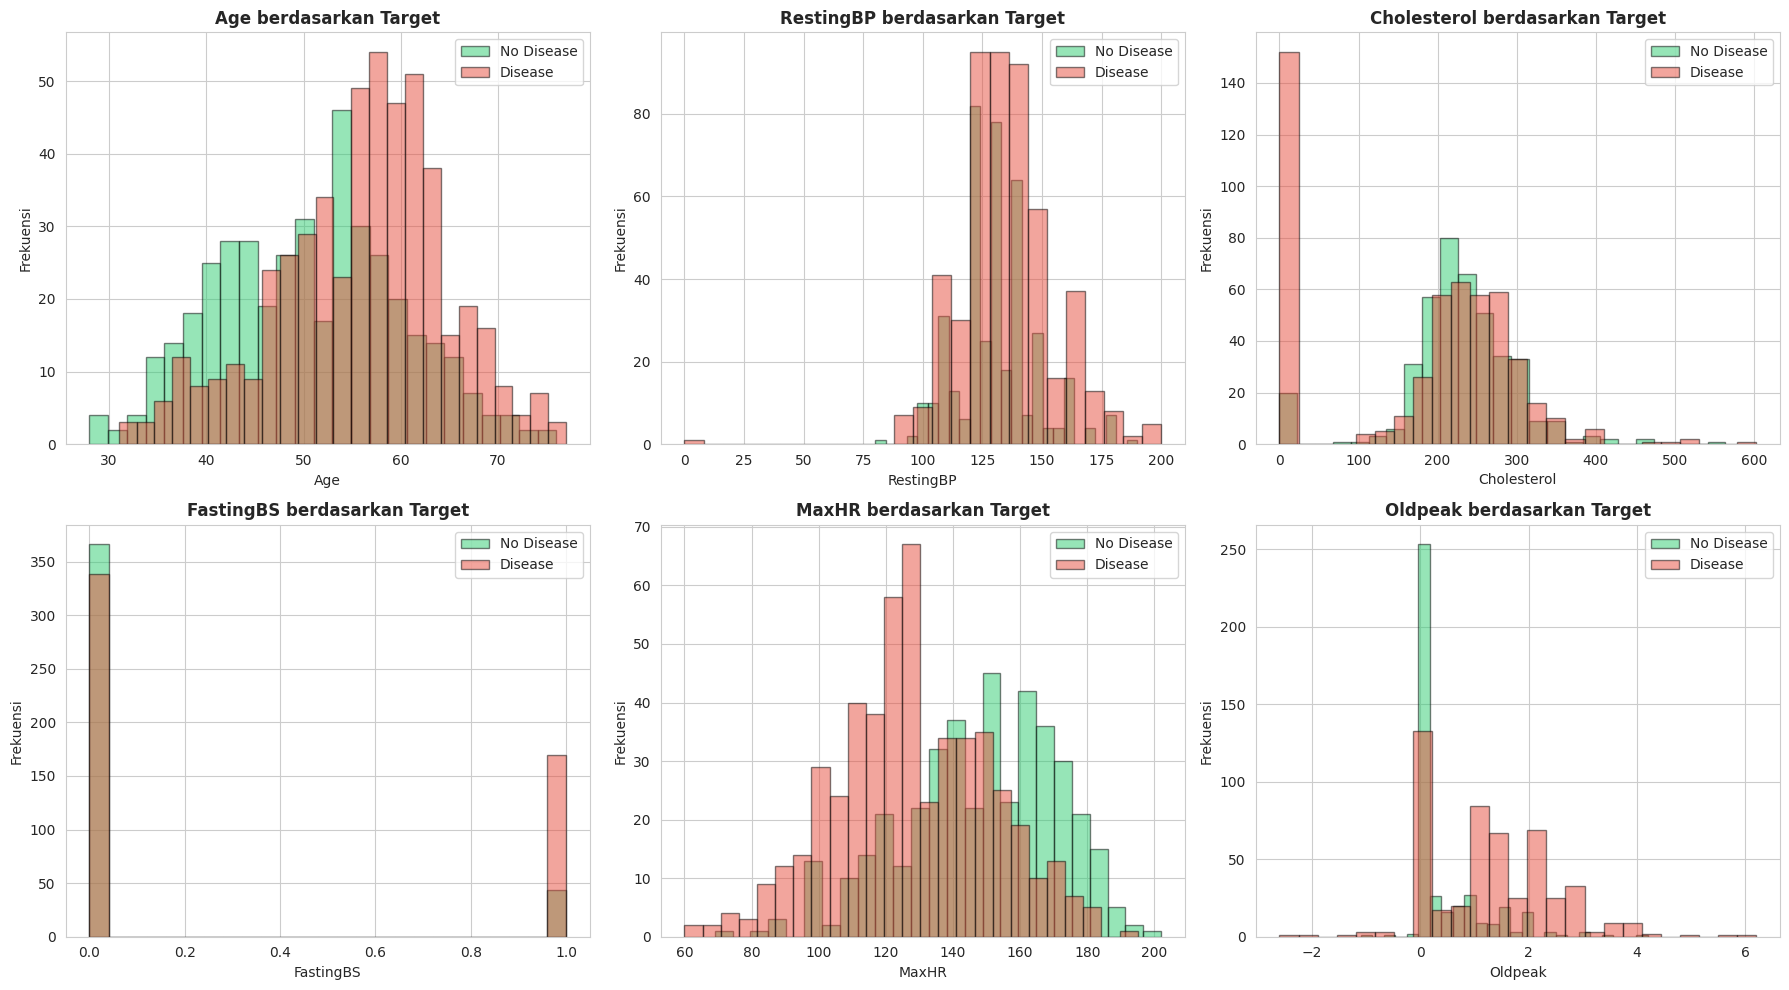

In [11]:
# Distribusi fitur numerikal berdasarkan target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for target_val, label, color in [(0, 'No Disease', '#2ecc71'), (1, 'Disease', '#e74c3c')]:
        subset = df[df['HeartDisease'] == target_val][col]
        axes[i].hist(subset, bins=25, alpha=0.5, label=label, color=color, edgecolor='black')
    axes[i].set_title(f'{col} berdasarkan Target', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.tight_layout()
plt.show()

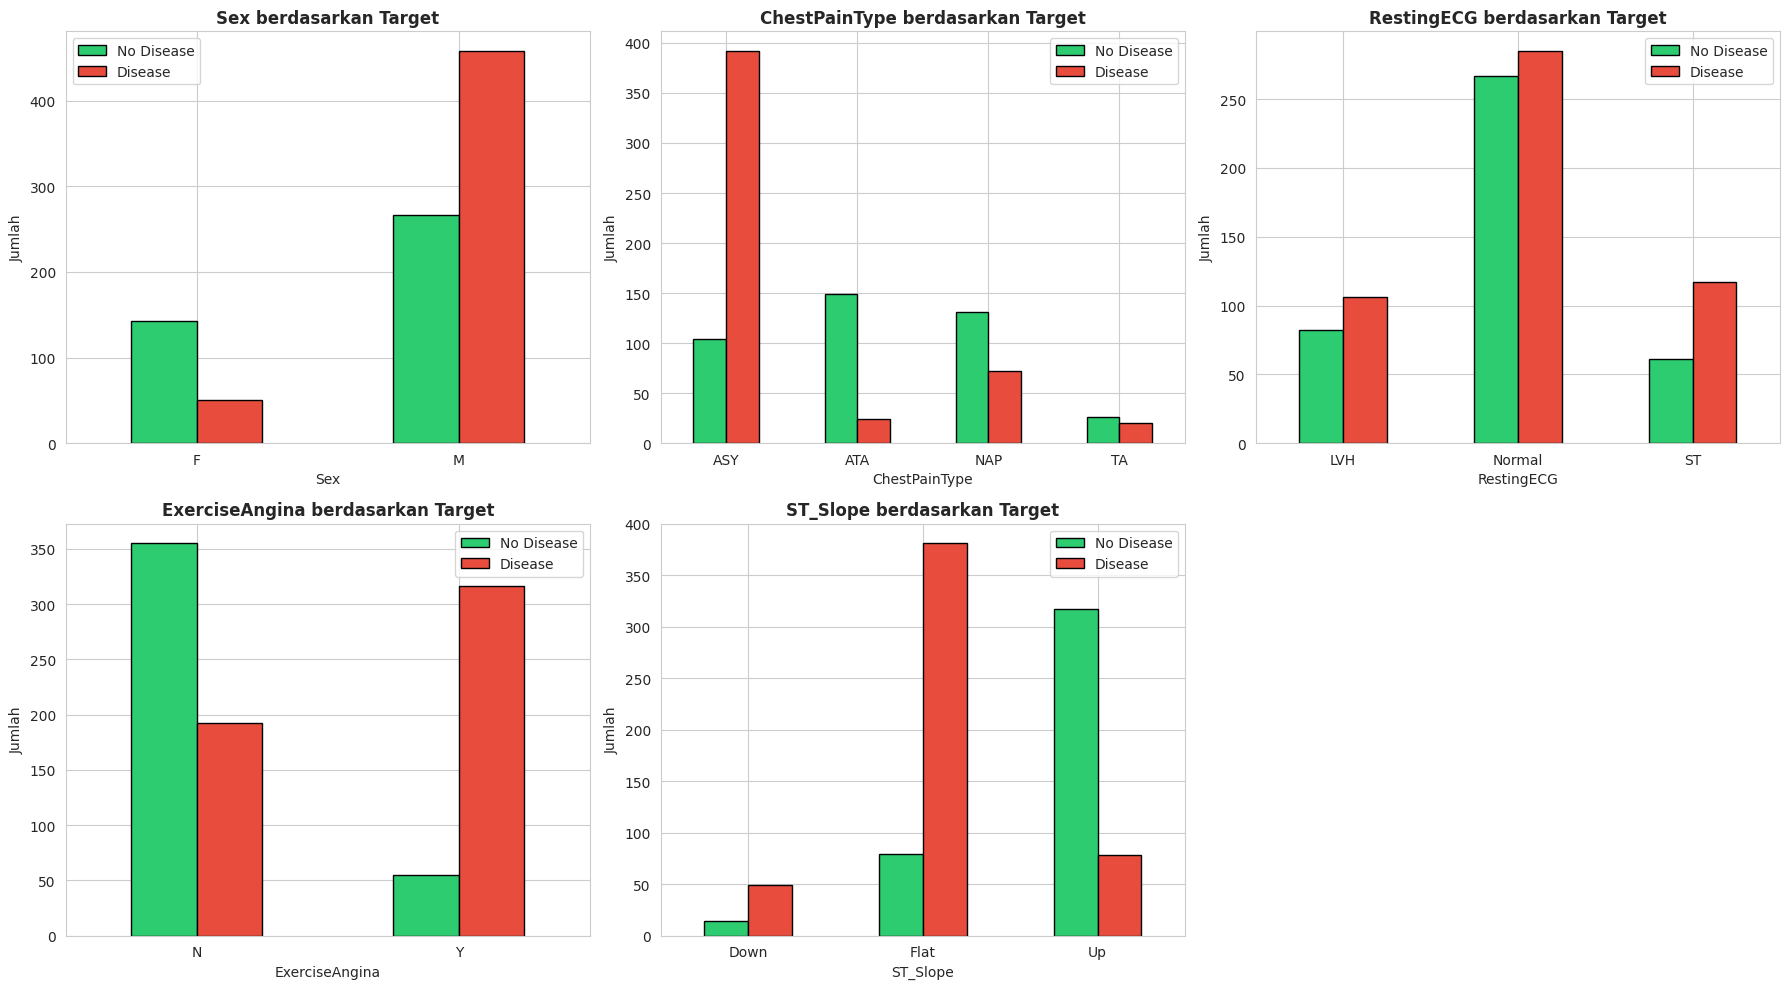

In [12]:
# Distribusi fitur kategorikal
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Count plot with target hue
    ct = pd.crosstab(df[col], df['HeartDisease'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'{col} berdasarkan Target', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(['No Disease', 'Disease'])
    axes[i].tick_params(axis='x', rotation=0)

# Hide empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

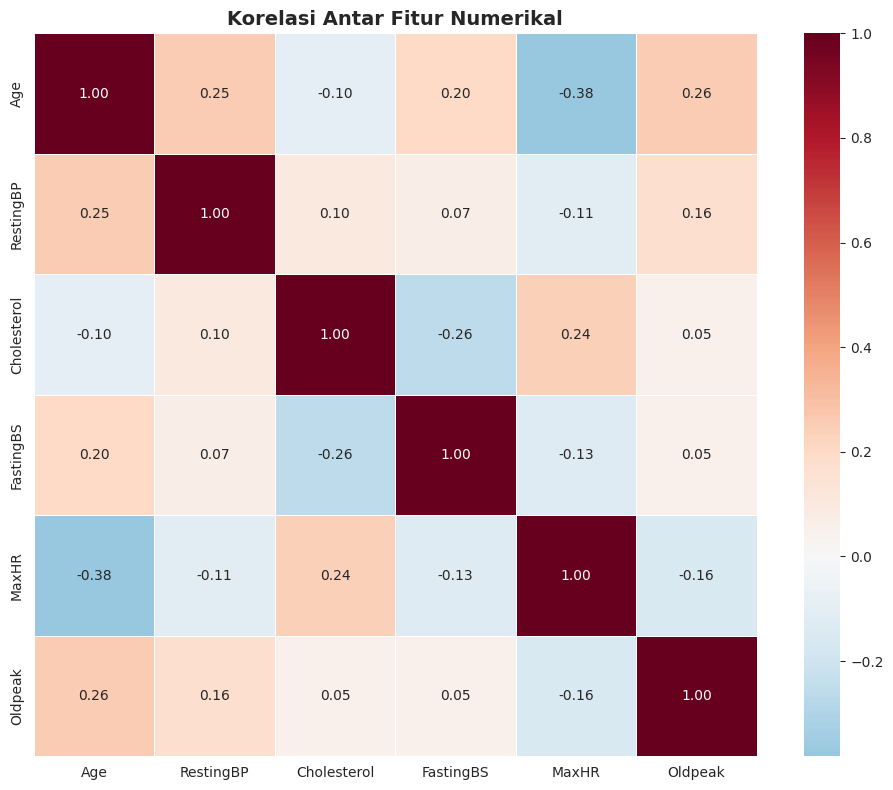

In [13]:
# Korelasi antar fitur numerikal
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Korelasi Antar Fitur Numerikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Deteksi nilai tidak wajar (RestingBP=0, Cholesterol=0)
print('=== Deteksi Nilai Tidak Wajar ===\n')

print(f'RestingBP == 0: {(df["RestingBP"] == 0).sum()} baris')
print(f'Cholesterol == 0: {(df["Cholesterol"] == 0).sum()} baris')

print(f'\nContoh baris dengan RestingBP=0:')
display(df[df['RestingBP'] == 0].head(3))

print(f'\nContoh baris dengan Cholesterol=0:')
display(df[df['Cholesterol'] == 0].head(3))

=== Deteksi Nilai Tidak Wajar ===

RestingBP == 0: 1 baris
Cholesterol == 0: 172 baris

Contoh baris dengan RestingBP=0:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1



Contoh baris dengan Cholesterol=0:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1


**Kesimpulan EDA:**
- Dataset cukup seimbang (55.3% Disease vs 44.7% No Disease)
- Terdapat nilai 0 pada `RestingBP` (1 baris) dan `Cholesterol` (172 baris) yang tidak wajar secara medis — perlu ditangani
- Fitur kategorikal seperti `ChestPainType` dan `ST_Slope` menunjukkan perbedaan signifikan antar target
- `FastingBS` dan `MaxHR` berkorelasi dengan target
- Tidak ada missing value eksplisit

# **5. Data Preprocessing**

Tahapan preprocessing:
1. Menangani nilai 0 pada RestingBP dan Cholesterol (dianggap sebagai missing value)
2. Encoding fitur kategorikal dengan Label Encoding
3. Standarisasi fitur numerikal dengan StandardScaler
4. Split data menjadi training dan testing set
5. Menyimpan dataset hasil preprocessing

In [15]:
# Salin dataframe untuk preprocessing
df_clean = df.copy()

print(f'Shape sebelum preprocessing: {df_clean.shape}')

Shape sebelum preprocessing: (918, 12)


In [16]:
# 1. Menangani nilai 0 (missing value tersembunyi)
# RestingBP = 0 → ganti dengan median
bp_median = df_clean.loc[df_clean['RestingBP'] > 0, 'RestingBP'].median()
df_clean['RestingBP'] = df_clean['RestingBP'].replace(0, bp_median)
print(f'RestingBP: {sum(df["RestingBP"] == 0)} nilai 0 → diganti median ({bp_median})')

# Cholesterol = 0 → ganti dengan median
chol_median = df_clean.loc[df_clean['Cholesterol'] > 0, 'Cholesterol'].median()
df_clean['Cholesterol'] = df_clean['Cholesterol'].replace(0, chol_median)
print(f'Cholesterol: {sum(df["Cholesterol"] == 0)} nilai 0 → diganti median ({chol_median})')

print(f'\nVerifikasi setelah handling missing:')
print(f'RestingBP == 0: {(df_clean["RestingBP"] == 0).sum()}')
print(f'Cholesterol == 0: {(df_clean["Cholesterol"] == 0).sum()}')

RestingBP: 1 nilai 0 → diganti median (130.0)
Cholesterol: 172 nilai 0 → diganti median (237.0)

Verifikasi setelah handling missing:
RestingBP == 0: 0
Cholesterol == 0: 0


In [17]:
# 2. Encoding fitur kategorikal dengan LabelEncoder
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nData setelah encoding:')
display(df_clean.head())

Sex: {'F': np.int64(0), 'M': np.int64(1)}
ChestPainType: {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
RestingECG: {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
ExerciseAngina: {'N': np.int64(0), 'Y': np.int64(1)}
ST_Slope: {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}

Data setelah encoding:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [18]:
# 3. Split fitur dan target
X = df_clean.drop('HeartDisease', axis=1)
y = df_clean['HeartDisease']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (918, 11)
y shape: (918,)


In [19]:
# 4. Standarisasi fitur numerikal dengan StandardScaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

print('Statistik setelah standarisasi:')
print(X_scaled[num_cols].describe().round(2))

print(f'\nMean (harus ~0):')
print(X_scaled[num_cols].mean().round(4))
print(f'\nStd (harus ~1):')
print(X_scaled[num_cols].std().round(4))

Statistik setelah standarisasi:
          Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak
count  918.00     918.00       918.00     918.00  918.00   918.00
mean    -0.00       0.00         0.00      -0.00    0.00     0.00
std      1.00       1.00         1.00       1.00    1.00     1.00
min     -2.71      -2.92        -2.96      -0.55   -3.02    -3.27
25%     -0.69      -0.70        -0.55      -0.55   -0.66    -0.83
50%      0.05      -0.14        -0.12      -0.55    0.05    -0.27
75%      0.69       0.42         0.45      -0.55    0.75     0.57
max      2.49       3.75         6.74       1.81    2.56     4.98

Mean (harus ~0):
Age           -0.0
RestingBP      0.0
Cholesterol    0.0
FastingBS     -0.0
MaxHR          0.0
Oldpeak        0.0
dtype: float64

Std (harus ~1):
Age            1.0005
RestingBP      1.0005
Cholesterol    1.0005
FastingBS      1.0005
MaxHR          1.0005
Oldpeak        1.0005
dtype: float64


In [20]:
# 5. Split train dan test set
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

print(f'\nDistribusi target di training set:')
print(f'  No Disease: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.1f}%)')
print(f'  Disease:    {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.1f}%)')

print(f'\nDistribusi target di test set:')
print(f'  No Disease: {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.1f}%)')
print(f'  Disease:    {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.1f}%)')

X_train shape: (734, 11)
X_test shape:  (184, 11)
y_train shape: (734,)
y_test shape:  (184,)

Distribusi target di training set:
  No Disease: 328 (44.7%)
  Disease:    406 (55.3%)

Distribusi target di test set:
  No Disease: 82 (44.6%)
  Disease:    102 (55.4%)


In [21]:
# 6. Simpan dataset hasil preprocessing
import os

output_dir = './heart_failure_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Gabungkan X dan y untuk train dan test
train_data = X_train.copy()
train_data['HeartDisease'] = y_train.values

test_data = X_test.copy()
test_data['HeartDisease'] = y_test.values

# Simpan ke CSV
train_data.to_csv(f'{output_dir}/heart_train.csv', index=False)
test_data.to_csv(f'{output_dir}/heart_test.csv', index=False)

# Simpan juga dataset full yang sudah dipreprocessing
df_clean.to_csv(f'{output_dir}/heart_clean.csv', index=False)

print(f'✅ Dataset disimpan di {output_dir}/')
print(f'   - heart_train.csv ({train_data.shape[0]} baris)')
print(f'   - heart_test.csv  ({test_data.shape[0]} baris)')
print(f'   - heart_clean.csv ({df_clean.shape[0]} baris)')

✅ Dataset disimpan di ./heart_failure_preprocessing/
   - heart_train.csv (734 baris)
   - heart_test.csv  (184 baris)
   - heart_clean.csv (918 baris)


## **Kesimpulan Preprocessing**

Tahapan preprocessing yang telah dilakukan:
1. ✅ **Handling missing value tersembunyi**: RestingBP=0 (1 baris) dan Cholesterol=0 (172 baris) diganti dengan median
2. ✅ **Label Encoding**: 5 fitur kategorikal diubah ke numerik (Sex, ChestPainType, RestingECG, ExerciseAngina, ST_Slope)
3. ✅ **Standard Scaling**: 6 fitur numerikal distandarisasi (mean=0, std=1)
4. ✅ **Train-Test Split**: 80-20 dengan stratifikasi
5. ✅ **Dataset disimpan**: heart_train.csv, heart_test.csv, heart_clean.csv

Dataset siap digunakan untuk modelling di Kriteria 2.